📊 Data Overview:
Shape: (9, 54)
Columns: ['Series Name', 'Series Code', 'Country Name', 'Country Code', '1976 [YR1976]', '1977 [YR1977]', '1978 [YR1978]', '1979 [YR1979]', '1980 [YR1980]', '1981 [YR1981]']...

✅ Converted to long format:
Records: 450
Years: 1976 - 2025
Countries: ['AUS', 'CHN', 'FIN', 'FRA', 'DEU', 'ITA', 'JPN', 'USA', 'GBR']

📈 Latest Year Analysis:
Latest year: 2025
Countries with data: 0

🏆 Top 5 Highest Inflation:

📉 Top 5 Lowest Inflation:


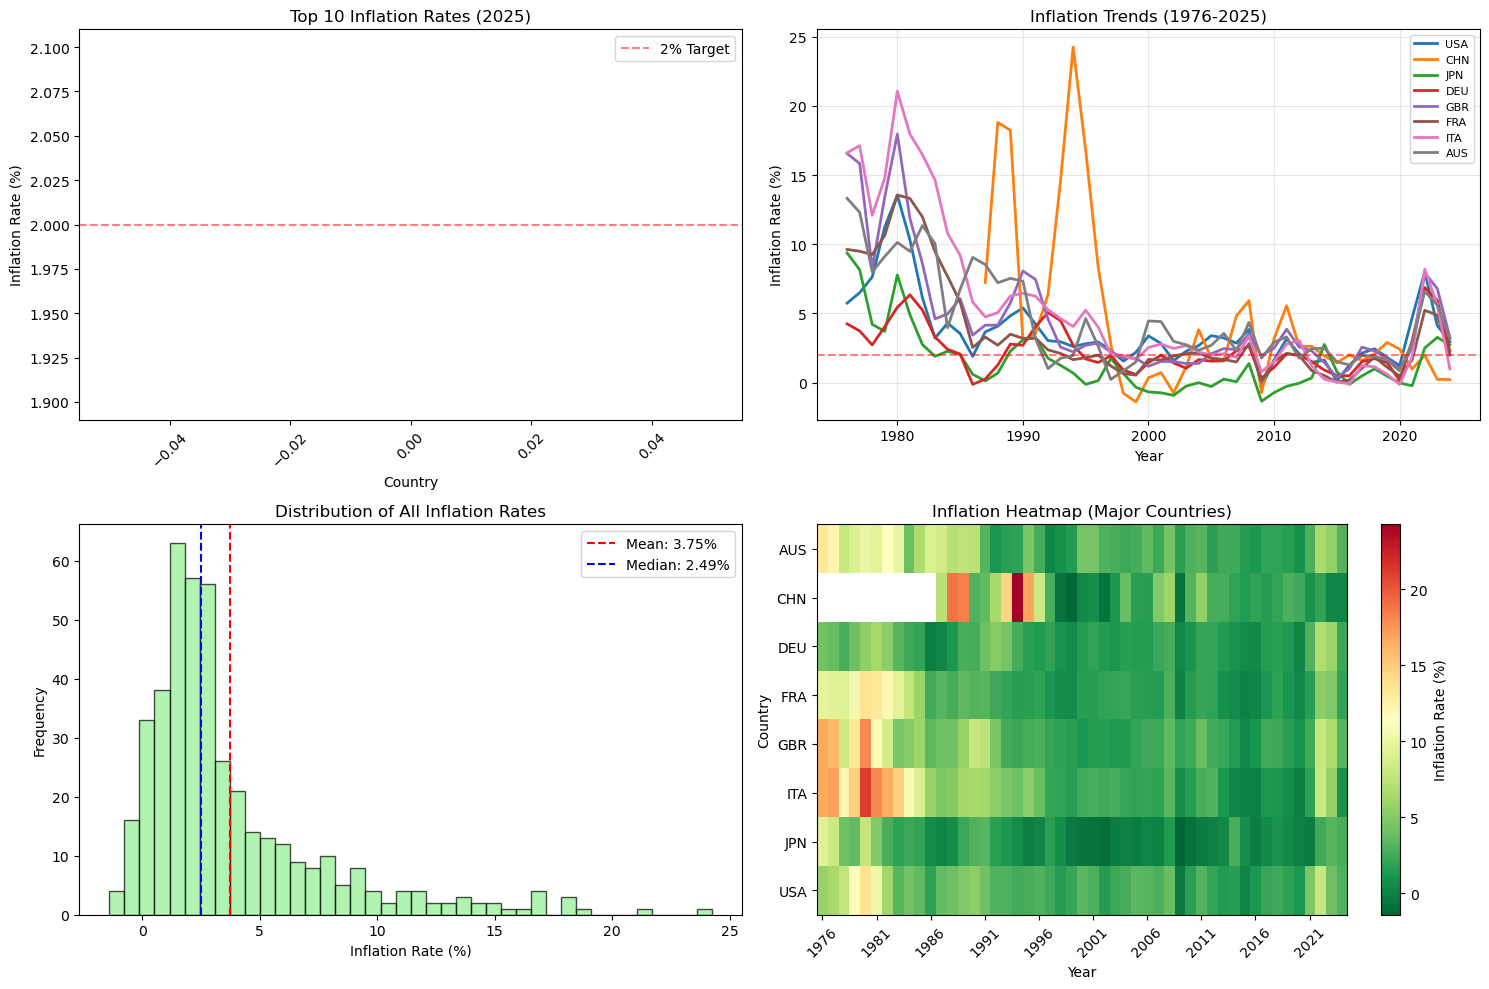


📊 Summary Statistics:
----------------------------------------

📈 Average Inflation by Country:
  USA: Mean=3.70%, Std=2.69%
  CHN: Mean=4.53%, Std=6.05%
  JPN: Mean=1.49%, Std=2.31%
  DEU: Mean=2.38%, Std=1.70%
  GBR: Mean=4.56%, Std=4.22%
  FRA: Mean=3.56%, Std=3.65%
  ITA: Mean=5.41%, Std=5.51%
  AUS: Mean=4.57%, Std=3.40%

🌍 Global Statistics:
  Mean inflation: 3.75%
  Median inflation: 2.49%
  Standard deviation: 3.98%
  Range: -1.40% to 24.26%

✅ Analysis Complete!


In [1]:
# ==================== 1. IMPORT LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================== 2. LOAD DATA ====================
# Load the inflation data
df = pd.read_csv('inflation.csv')

print("📊 Data Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])}...")

# ==================== 3. CONVERT TO LONG FORMAT ====================
# Identify year columns (they contain [YR...])
year_columns = [col for col in df.columns if '[YR' in col]

# Melt to long format
df_long = pd.melt(
    df, 
    id_vars=['Country Name', 'Country Code'],
    value_vars=year_columns,
    var_name='Year',
    value_name='Inflation_Rate'
)

# Extract year number
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)
df_long['Inflation_Rate'] = pd.to_numeric(df_long['Inflation_Rate'], errors='coerce')

print(f"\n✅ Converted to long format:")
print(f"Records: {len(df_long)}")
print(f"Years: {df_long['Year'].min()} - {df_long['Year'].max()}")
print(f"Countries: {df_long['Country Code'].unique().tolist()}")

# ==================== 4. BASIC ANALYSIS ====================
print("\n📈 Latest Year Analysis:")
latest_year = df_long['Year'].max()
latest_data = df_long[df_long['Year'] == latest_year].dropna()

print(f"Latest year: {latest_year}")
print(f"Countries with data: {len(latest_data)}")

# Top and bottom countries
top5 = latest_data.nlargest(5, 'Inflation_Rate')
bottom5 = latest_data.nsmallest(5, 'Inflation_Rate')

print("\n🏆 Top 5 Highest Inflation:")
for _, row in top5.iterrows():
    print(f"  {row['Country Code']}: {row['Inflation_Rate']:.2f}%")

print("\n📉 Top 5 Lowest Inflation:")
for _, row in bottom5.iterrows():
    print(f"  {row['Country Code']}: {row['Inflation_Rate']:.2f}%")

# ==================== 5. VISUALIZATIONS ====================
plt.figure(figsize=(15, 10))

# Plot 1: Latest inflation rates
plt.subplot(2, 2, 1)
sorted_latest = latest_data.sort_values('Inflation_Rate', ascending=False)
plt.bar(sorted_latest['Country Code'][:10], sorted_latest['Inflation_Rate'][:10], color='skyblue')
plt.title(f'Top 10 Inflation Rates ({latest_year})')
plt.xlabel('Country')
plt.ylabel('Inflation Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='2% Target')
plt.legend()

# Plot 2: Time series for major economies
plt.subplot(2, 2, 2)
major_countries = ['USA', 'CHN', 'JPN', 'DEU', 'GBR', 'FRA', 'ITA', 'AUS']

for country in major_countries:
    country_data = df_long[df_long['Country Code'] == country]
    if not country_data.empty:
        plt.plot(country_data['Year'], country_data['Inflation_Rate'], label=country, linewidth=2)

plt.title('Inflation Trends (1976-2025)')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.axhline(y=2, color='red', linestyle='--', alpha=0.5)

# Plot 3: Distribution
plt.subplot(2, 2, 3)
all_rates = df_long['Inflation_Rate'].dropna()
plt.hist(all_rates, bins=40, edgecolor='black', alpha=0.7, color='lightgreen')
plt.title('Distribution of All Inflation Rates')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Frequency')
plt.axvline(x=all_rates.mean(), color='red', linestyle='--', label=f'Mean: {all_rates.mean():.2f}%')
plt.axvline(x=all_rates.median(), color='blue', linestyle='--', label=f'Median: {all_rates.median():.2f}%')
plt.legend()

# Plot 4: Heatmap of major countries
plt.subplot(2, 2, 4)
heatmap_data = df_long[df_long['Country Code'].isin(major_countries)].pivot_table(
    index='Country Code', 
    columns='Year', 
    values='Inflation_Rate'
)
plt.imshow(heatmap_data, aspect='auto', cmap='RdYlGn_r')
plt.colorbar(label='Inflation Rate (%)')
plt.title('Inflation Heatmap (Major Countries)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.xticks(range(0, len(heatmap_data.columns), 5), heatmap_data.columns[::5], rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.tight_layout()
plt.show()

# ==================== 6. SUMMARY STATISTICS ====================
print("\n📊 Summary Statistics:")
print("-" * 40)

# By country
country_stats = df_long.groupby('Country Code')['Inflation_Rate'].agg(['mean', 'std', 'min', 'max']).round(2)

print("\n📈 Average Inflation by Country:")
for country in major_countries:
    if country in country_stats.index:
        stats = country_stats.loc[country]
        print(f"  {country}: Mean={stats['mean']:.2f}%, Std={stats['std']:.2f}%")

# Global statistics
print(f"\n🌍 Global Statistics:")
print(f"  Mean inflation: {all_rates.mean():.2f}%")
print(f"  Median inflation: {all_rates.median():.2f}%")
print(f"  Standard deviation: {all_rates.std():.2f}%")
print(f"  Range: {all_rates.min():.2f}% to {all_rates.max():.2f}%")

print("\n✅ Analysis Complete!")

📊 Data loaded successfully
Shape: (9, 54)
Sample data:
                             Series Name     Series Code Country Name  \
0  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG    Australia   
1  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG        China   
2  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG      Finland   
3  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG       France   
4  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG      Germany   

  Country Code 1976 [YR1976] 1977 [YR1977] 1978 [YR1978] 1979 [YR1979]  \
0          AUS   13.32290298   12.30982675   8.004904394   9.122020569   
1          CHN            ..            ..            ..            ..   
2          FIN   14.34269309   11.79334692   7.799350746   7.466961513   
3          FRA   9.625495782   9.494554672   9.250558467   10.64673417   
4          DEU   4.246631023   3.734162406   2.718696961   4.043620065   

  1980 [YR1980] 1981 [YR1981]  ... 2016 [YR2016] 2017 [YR2017

/var/folders/9w/g95tn4hs07d851nhtyqv55vr0000gn/T/ipykernel_48764/1330864120.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(all_countries))


✅ Chart created for CHN: inflation_CHN.png
✅ Chart created for FIN: inflation_FIN.png
✅ Chart created for FRA: inflation_FRA.png
✅ Chart created for DEU: inflation_DEU.png
✅ Chart created for ITA: inflation_ITA.png
✅ Chart created for JPN: inflation_JPN.png
✅ Chart created for USA: inflation_USA.png
✅ Chart created for GBR: inflation_GBR.png

🎉 9 individual charts created successfully!

📊 Creating comparison chart with all countries...


/var/folders/9w/g95tn4hs07d851nhtyqv55vr0000gn/T/ipykernel_48764/1330864120.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_comparison = cm.get_cmap('tab20', len(all_countries))


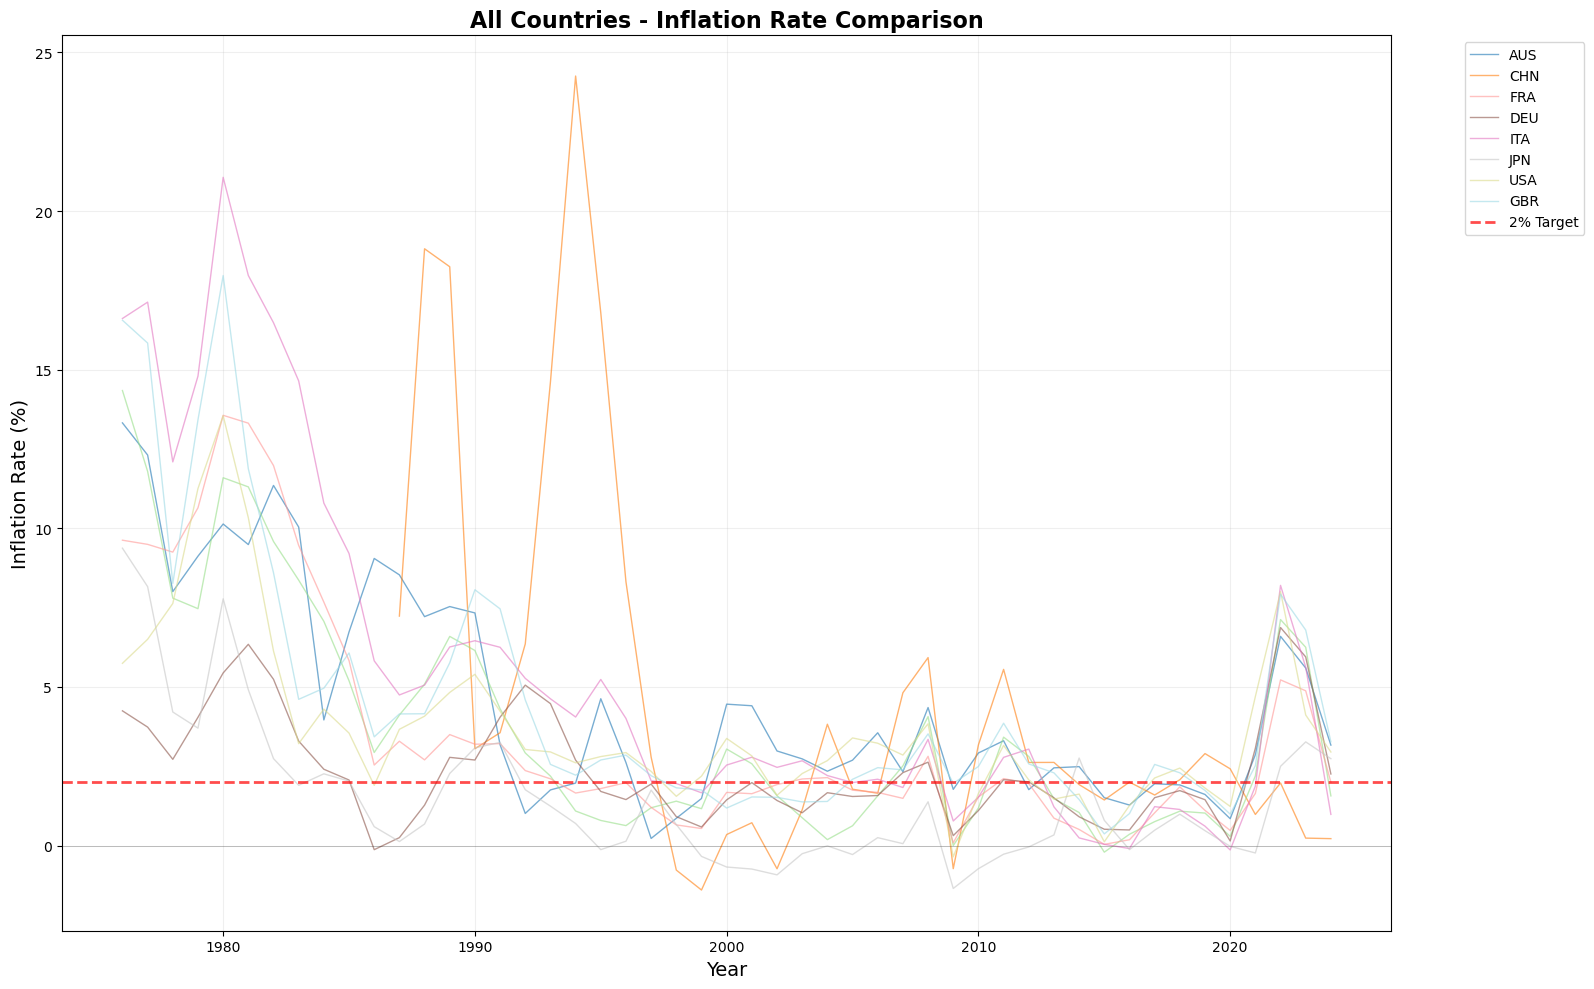

✅ Comparison chart saved: inflation_comparison_all.png

🎨 Creating color-coded summary chart...


/var/folders/9w/g95tn4hs07d851nhtyqv55vr0000gn/T/ipykernel_48764/1330864120.py:172: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_summary = cm.get_cmap('tab20', len(major_countries))


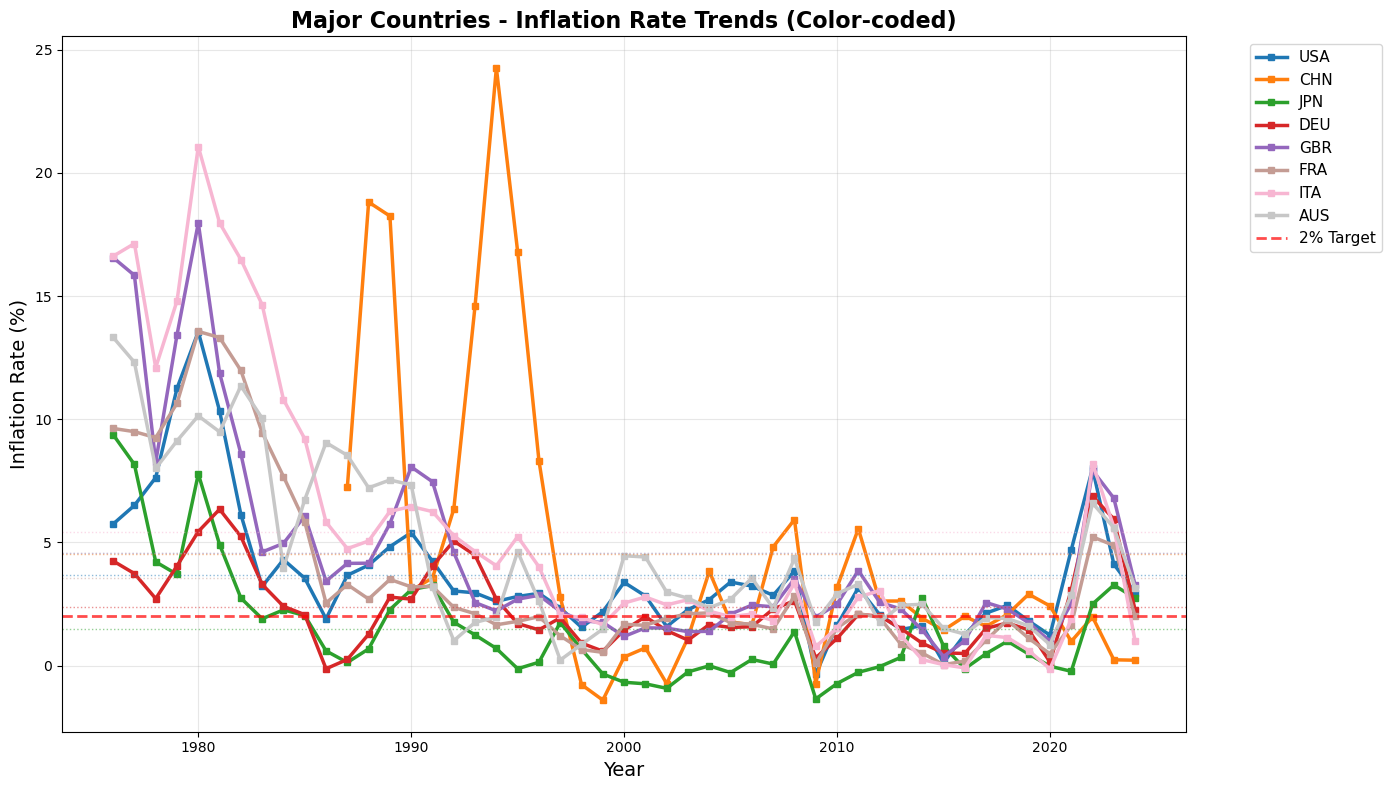

✅ Color-coded summary saved: inflation_major_countries_colored.png

📈 Statistics Summary:
Major Countries Statistics:
----------------------------------------

USA:
  Average Inflation: 3.70%
  Volatility (Std Dev): 2.69%
  Range: -0.36% to 13.55%
  Data Points: 49

CHN:
  Average Inflation: 4.53%
  Volatility (Std Dev): 6.05%
  Range: -1.40% to 24.26%
  Data Points: 38

JPN:
  Average Inflation: 1.49%
  Volatility (Std Dev): 2.31%
  Range: -1.35% to 9.37%
  Data Points: 49

DEU:
  Average Inflation: 2.38%
  Volatility (Std Dev): 1.70%
  Range: -0.13% to 6.87%
  Data Points: 49

GBR:
  Average Inflation: 4.56%
  Volatility (Std Dev): 4.22%
  Range: 0.37% to 17.97%
  Data Points: 49

FRA:
  Average Inflation: 3.56%
  Volatility (Std Dev): 3.65%
  Range: 0.04% to 13.56%
  Data Points: 49

ITA:
  Average Inflation: 5.41%
  Volatility (Std Dev): 5.51%
  Range: -0.14% to 21.06%
  Data Points: 49

AUS:
  Average Inflation: 4.57%
  Volatility (Std Dev): 3.40%
  Range: 0.22% to 13.32%
  Data P

In [3]:
# ==================== 1. IMPORT LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ==================== 2. LOAD AND PREPARE DATA ====================
# Load the inflation data
df = pd.read_csv('inflation.csv')

print("📊 Data loaded successfully")
print(f"Shape: {df.shape}")
print(f"Sample data:")
print(df.head())

# Convert to long format
year_columns = [col for col in df.columns if '[YR' in col]

df_long = pd.melt(
    df, 
    id_vars=['Country Name', 'Country Code'],
    value_vars=year_columns,
    var_name='Year',
    value_name='Inflation_Rate'
)

# Extract year and convert to numeric
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)
df_long['Inflation_Rate'] = pd.to_numeric(df_long['Inflation_Rate'], errors='coerce')

print(f"\n✅ Data converted to long format:")
print(f"Total records: {len(df_long)}")
print(f"Year range: {df_long['Year'].min()} - {df_long['Year'].max()}")
print(f"Number of countries: {df_long['Country Code'].nunique()}")

# ==================== 3. CREATE INDIVIDUAL CHARTS FOR EACH COUNTRY ====================
# Get all unique countries
all_countries = df_long['Country Code'].unique()
print(f"\n🎨 Creating individual charts for {len(all_countries)} countries...")

# Create a color map for different colors
colors = cm.get_cmap('tab20', len(all_countries))

# Create individual charts
charts_created = 0
for i, country_code in enumerate(all_countries):
    # Get country data
    country_data = df_long[df_long['Country Code'] == country_code].dropna(subset=['Inflation_Rate'])
    
    if country_data.empty:
        continue
    
    country_name = country_data['Country Name'].iloc[0]
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Get unique color for this country
    color = colors(i)
    
    # Plot line chart
    plt.plot(country_data['Year'], country_data['Inflation_Rate'], 
             color=color, linewidth=2.5, marker='o', markersize=4, 
             label=f'{country_code} - {country_name}')
    
    # Fill area under the curve
    plt.fill_between(country_data['Year'], 0, country_data['Inflation_Rate'], 
                     color=color, alpha=0.2)
    
    # Add reference lines
    plt.axhline(y=2, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='2% Target')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
    
    # Calculate statistics
    mean_inflation = country_data['Inflation_Rate'].mean()
    max_inflation = country_data['Inflation_Rate'].max()
    min_inflation = country_data['Inflation_Rate'].min()
    latest_year = country_data['Year'].max()
    latest_inflation = country_data[country_data['Year'] == latest_year]['Inflation_Rate'].values
    
    # Add statistics text
    stats_text = f"Average: {mean_inflation:.2f}%\n"
    stats_text += f"Max: {max_inflation:.2f}%\n"
    stats_text += f"Min: {min_inflation:.2f}%\n"
    if len(latest_inflation) > 0:
        stats_text += f"Latest ({latest_year}): {latest_inflation[0]:.2f}%"
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Set chart properties
    plt.title(f'{country_code} - {country_name}\nInflation Rate Trend', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Inflation Rate (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Set x-axis ticks
    years = country_data['Year'].unique()
    if len(years) > 10:
        plt.xticks(years[::5], rotation=45)
    else:
        plt.xticks(years, rotation=45)
    
    plt.tight_layout()
    
    # Save individual chart
    filename = f'inflation_{country_code}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    
    charts_created += 1
    print(f"✅ Chart created for {country_code}: {filename}")

print(f"\n🎉 {charts_created} individual charts created successfully!")

# ==================== 4. CREATE COMPARISON CHART (ALL COUNTRIES) ====================
print(f"\n📊 Creating comparison chart with all countries...")

plt.figure(figsize=(16, 10))
colors_comparison = cm.get_cmap('tab20', len(all_countries))

for i, country_code in enumerate(all_countries):
    country_data = df_long[df_long['Country Code'] == country_code].dropna(subset=['Inflation_Rate'])
    
    if country_data.empty:
        continue
    
    color = colors_comparison(i)
    plt.plot(country_data['Year'], country_data['Inflation_Rate'], 
             color=color, linewidth=1, alpha=0.6, label=country_code)

# Add reference lines
plt.axhline(y=2, color='red', linestyle='--', alpha=0.7, linewidth=2, label='2% Target')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)

# Set chart properties
plt.title('All Countries - Inflation Rate Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Inflation Rate (%)', fontsize=14)
plt.grid(True, alpha=0.2)

# Show legend for major countries only (to avoid clutter)
major_countries = ['USA', 'CHN', 'JPN', 'DEU', 'GBR', 'FRA', 'ITA', 'AUS', 'CAN', 'IND']
handles, labels = plt.gca().get_legend_handles_labels()

# Filter to show only major countries in legend
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels):
    if label in major_countries or label == '2% Target':
        filtered_handles.append(handle)
        filtered_labels.append(label)

plt.legend(filtered_handles, filtered_labels, fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('inflation_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Comparison chart saved: inflation_comparison_all.png")

# ==================== 5. CREATE COLOR-CODED SUMMARY ====================
print(f"\n🎨 Creating color-coded summary chart...")

# Select major countries for better visualization
major_countries_data = df_long[df_long['Country Code'].isin(major_countries)]

plt.figure(figsize=(14, 8))
colors_summary = cm.get_cmap('tab20', len(major_countries))

for i, country_code in enumerate(major_countries):
    country_data = major_countries_data[major_countries_data['Country Code'] == country_code]
    
    if country_data.empty:
        continue
    
    color = colors_summary(i)
    plt.plot(country_data['Year'], country_data['Inflation_Rate'], 
             color=color, linewidth=2.5, marker='s', markersize=5, 
             label=country_code)

# Add reference lines
plt.axhline(y=2, color='red', linestyle='--', alpha=0.7, linewidth=2, label='2% Target')

# Set chart properties
plt.title('Major Countries - Inflation Rate Trends (Color-coded)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Inflation Rate (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.05, 1))

# Add average line for comparison
for i, country_code in enumerate(major_countries):
    country_data = major_countries_data[major_countries_data['Country Code'] == country_code]
    if not country_data.empty:
        avg = country_data['Inflation_Rate'].mean()
        color = colors_summary(i)
        plt.axhline(y=avg, color=color, linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('inflation_major_countries_colored.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Color-coded summary saved: inflation_major_countries_colored.png")

# ==================== 6. DISPLAY STATISTICS (FIXED VERSION) ====================
print(f"\n📈 Statistics Summary:")
print("=" * 50)

# Calculate statistics for each country (simpler version)
country_stats_simple = df_long.groupby('Country Code').agg({
    'Inflation_Rate': ['mean', 'std', 'min', 'max', 'count']
}).round(2)

# Flatten the multi-index columns
country_stats_simple.columns = ['_'.join(col).strip() for col in country_stats_simple.columns.values]

print("Major Countries Statistics:")
print("-" * 40)

for country in major_countries:
    if country in country_stats_simple.index:
        stats = country_stats_simple.loc[country]
        print(f"\n{country}:")
        print(f"  Average Inflation: {stats['Inflation_Rate_mean']:.2f}%")
        print(f"  Volatility (Std Dev): {stats['Inflation_Rate_std']:.2f}%")
        print(f"  Range: {stats['Inflation_Rate_min']:.2f}% to {stats['Inflation_Rate_max']:.2f}%")
        print(f"  Data Points: {int(stats['Inflation_Rate_count'])}")

# Global statistics
print(f"\n🌍 Global Statistics:")
print("-" * 40)
print(f"Total data points: {len(df_long)}")
print(f"Global average inflation: {df_long['Inflation_Rate'].mean():.2f}%")
print(f"Global median inflation: {df_long['Inflation_Rate'].median():.2f}%")
print(f"Global inflation standard deviation: {df_long['Inflation_Rate'].std():.2f}%")

# Latest year analysis
latest_year = df_long['Year'].max()
latest_data = df_long[df_long['Year'] == latest_year].dropna()
print(f"\n📅 Latest Year Analysis ({latest_year}):")
print("-" * 40)
print(f"Countries with data: {len(latest_data)}")

if len(latest_data) > 0:
    # Top 5 highest inflation
    top5 = latest_data.nlargest(5, 'Inflation_Rate')
    print("\n🏆 Top 5 Highest Inflation:")
    for _, row in top5.iterrows():
        print(f"  {row['Country Code']}: {row['Inflation_Rate']:.2f}%")
    
    # Top 5 lowest inflation
    bottom5 = latest_data.nsmallest(5, 'Inflation_Rate')
    print("\n📉 Top 5 Lowest Inflation:")
    for _, row in bottom5.iterrows():
        print(f"  {row['Country Code']}: {row['Inflation_Rate']:.2f}%")

print(f"\n✅ Analysis complete!")
print(f"📁 Individual charts saved as: inflation_[country_code].png")
print(f"📁 Comparison charts saved as: inflation_comparison_all.png and inflation_major_countries_colored.png")

Creating sample data for demonstration...
Sample data created with 216 records

Basic Information:
Data Shape: (216, 4)
Columns: ['Country Code', 'Country Name', 'Year', 'Inflation_Rate']

First 5 rows:
  Country Code Country Name  Year  Inflation_Rate
0          USA  Country USA  2000        0.100000
1          USA  Country USA  2001        1.790342
2          USA  Country USA  2002        1.534729
3          USA  Country USA  2003        3.931918
4          USA  Country USA  2004        0.169852

Year range: 2000 - 2023
Number of countries: 9

Selected 9 countries: ['USA', 'CHN', 'JPN', 'DEU', 'GBR', 'FRA', 'ITA', 'IND', 'BRA']

Selected 9 countries - Code and Name:
USA: Country USA
CHN: Country CHN
JPN: Country JPN
DEU: Country DEU
GBR: Country GBR
FRA: Country FRA
ITA: Country ITA
IND: Country IND
BRA: Country BRA

1. Creating Inflation Rate Trend Comparison Chart for 9 Countries...


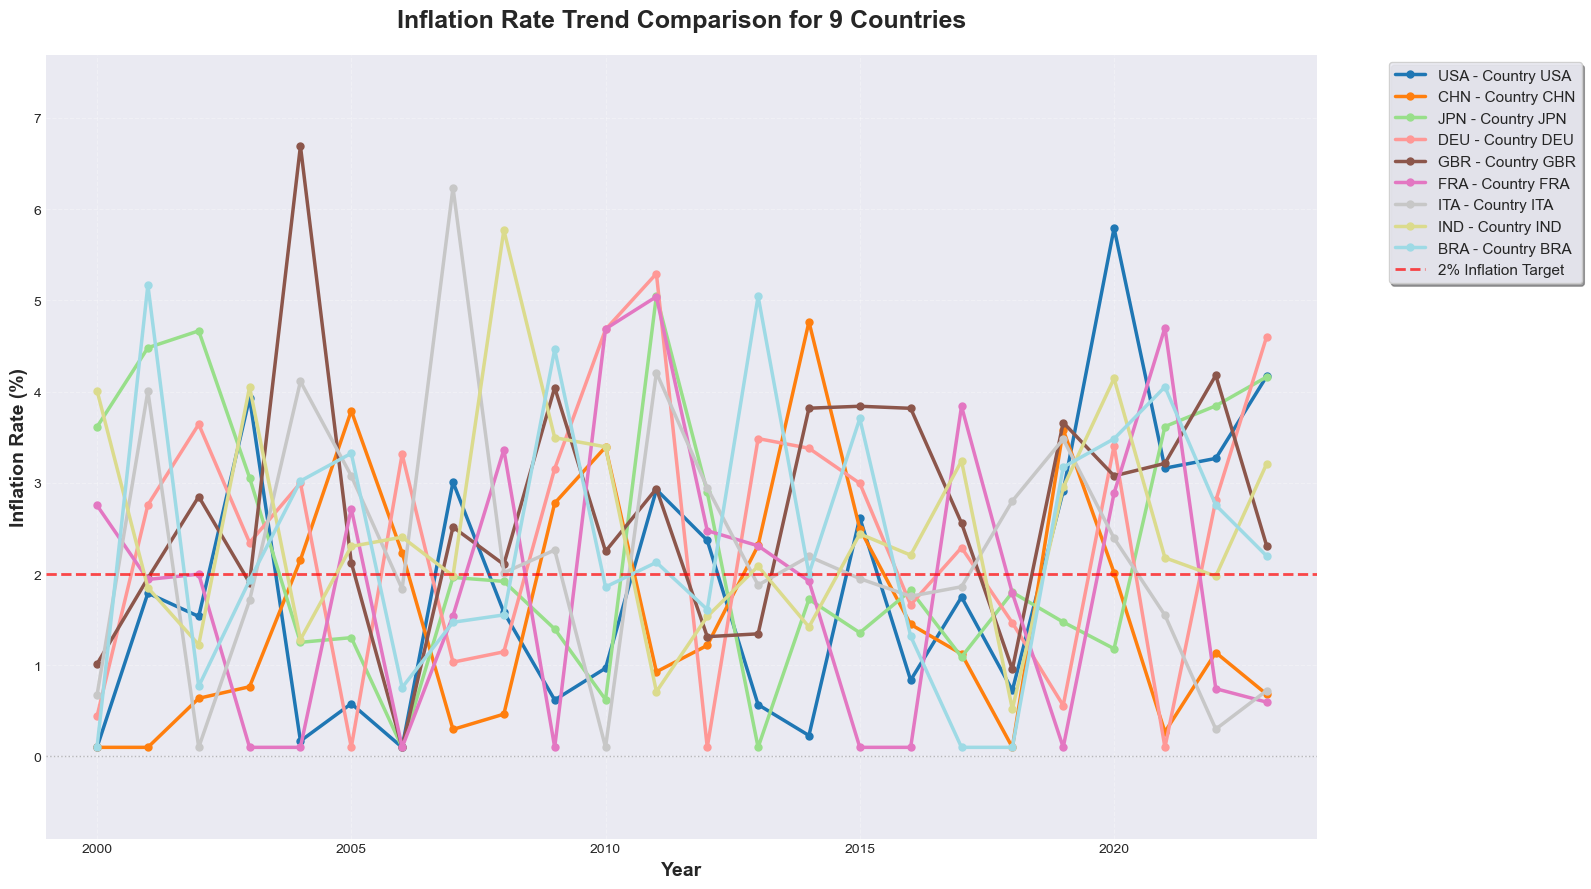


2. Creating Heatmap of Inflation Rates for 9 Countries...


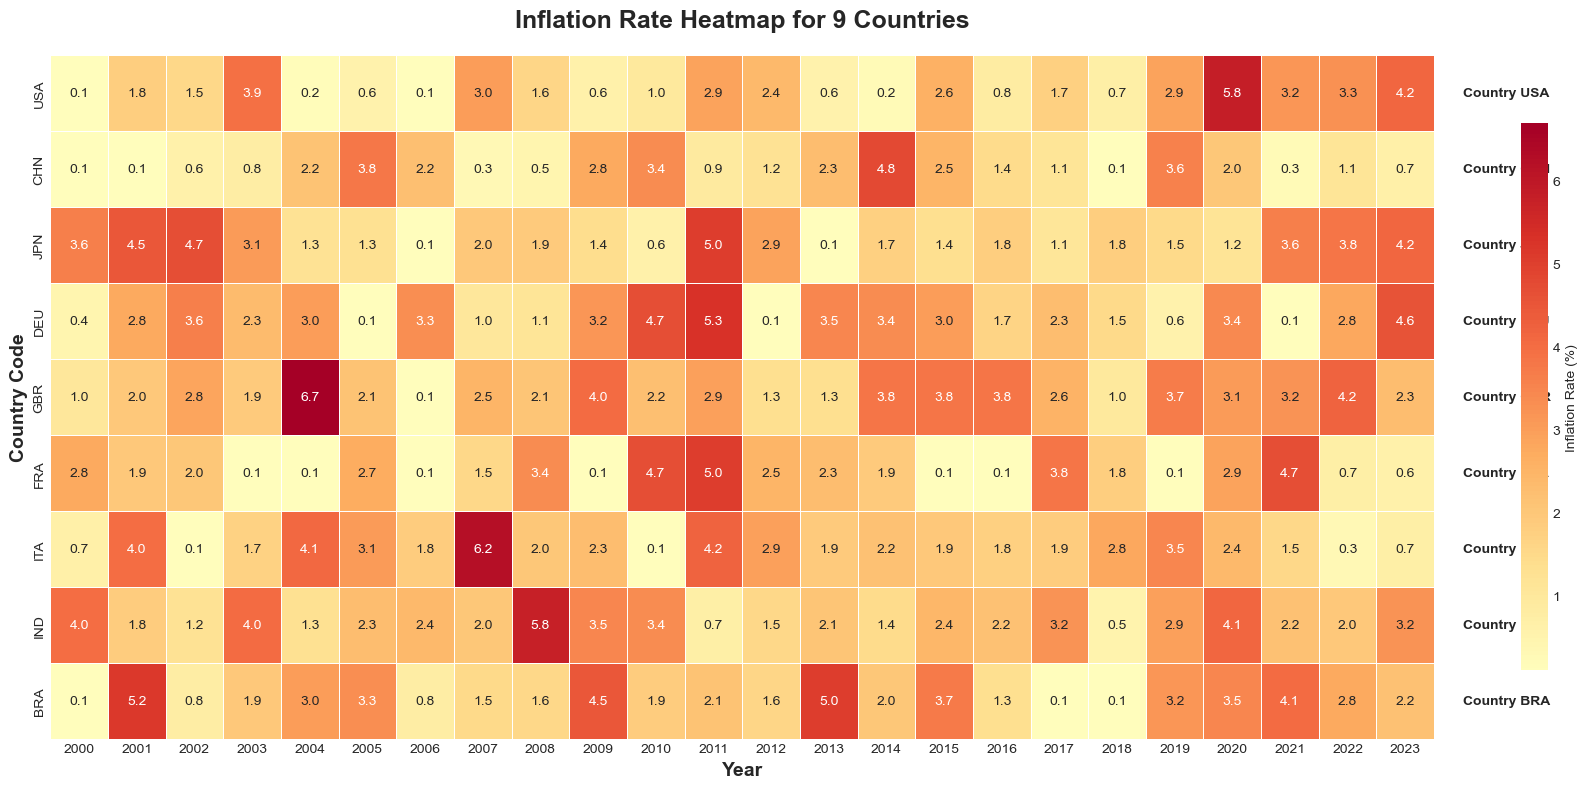


3. Creating Statistical Distribution Charts for 9 Countries...


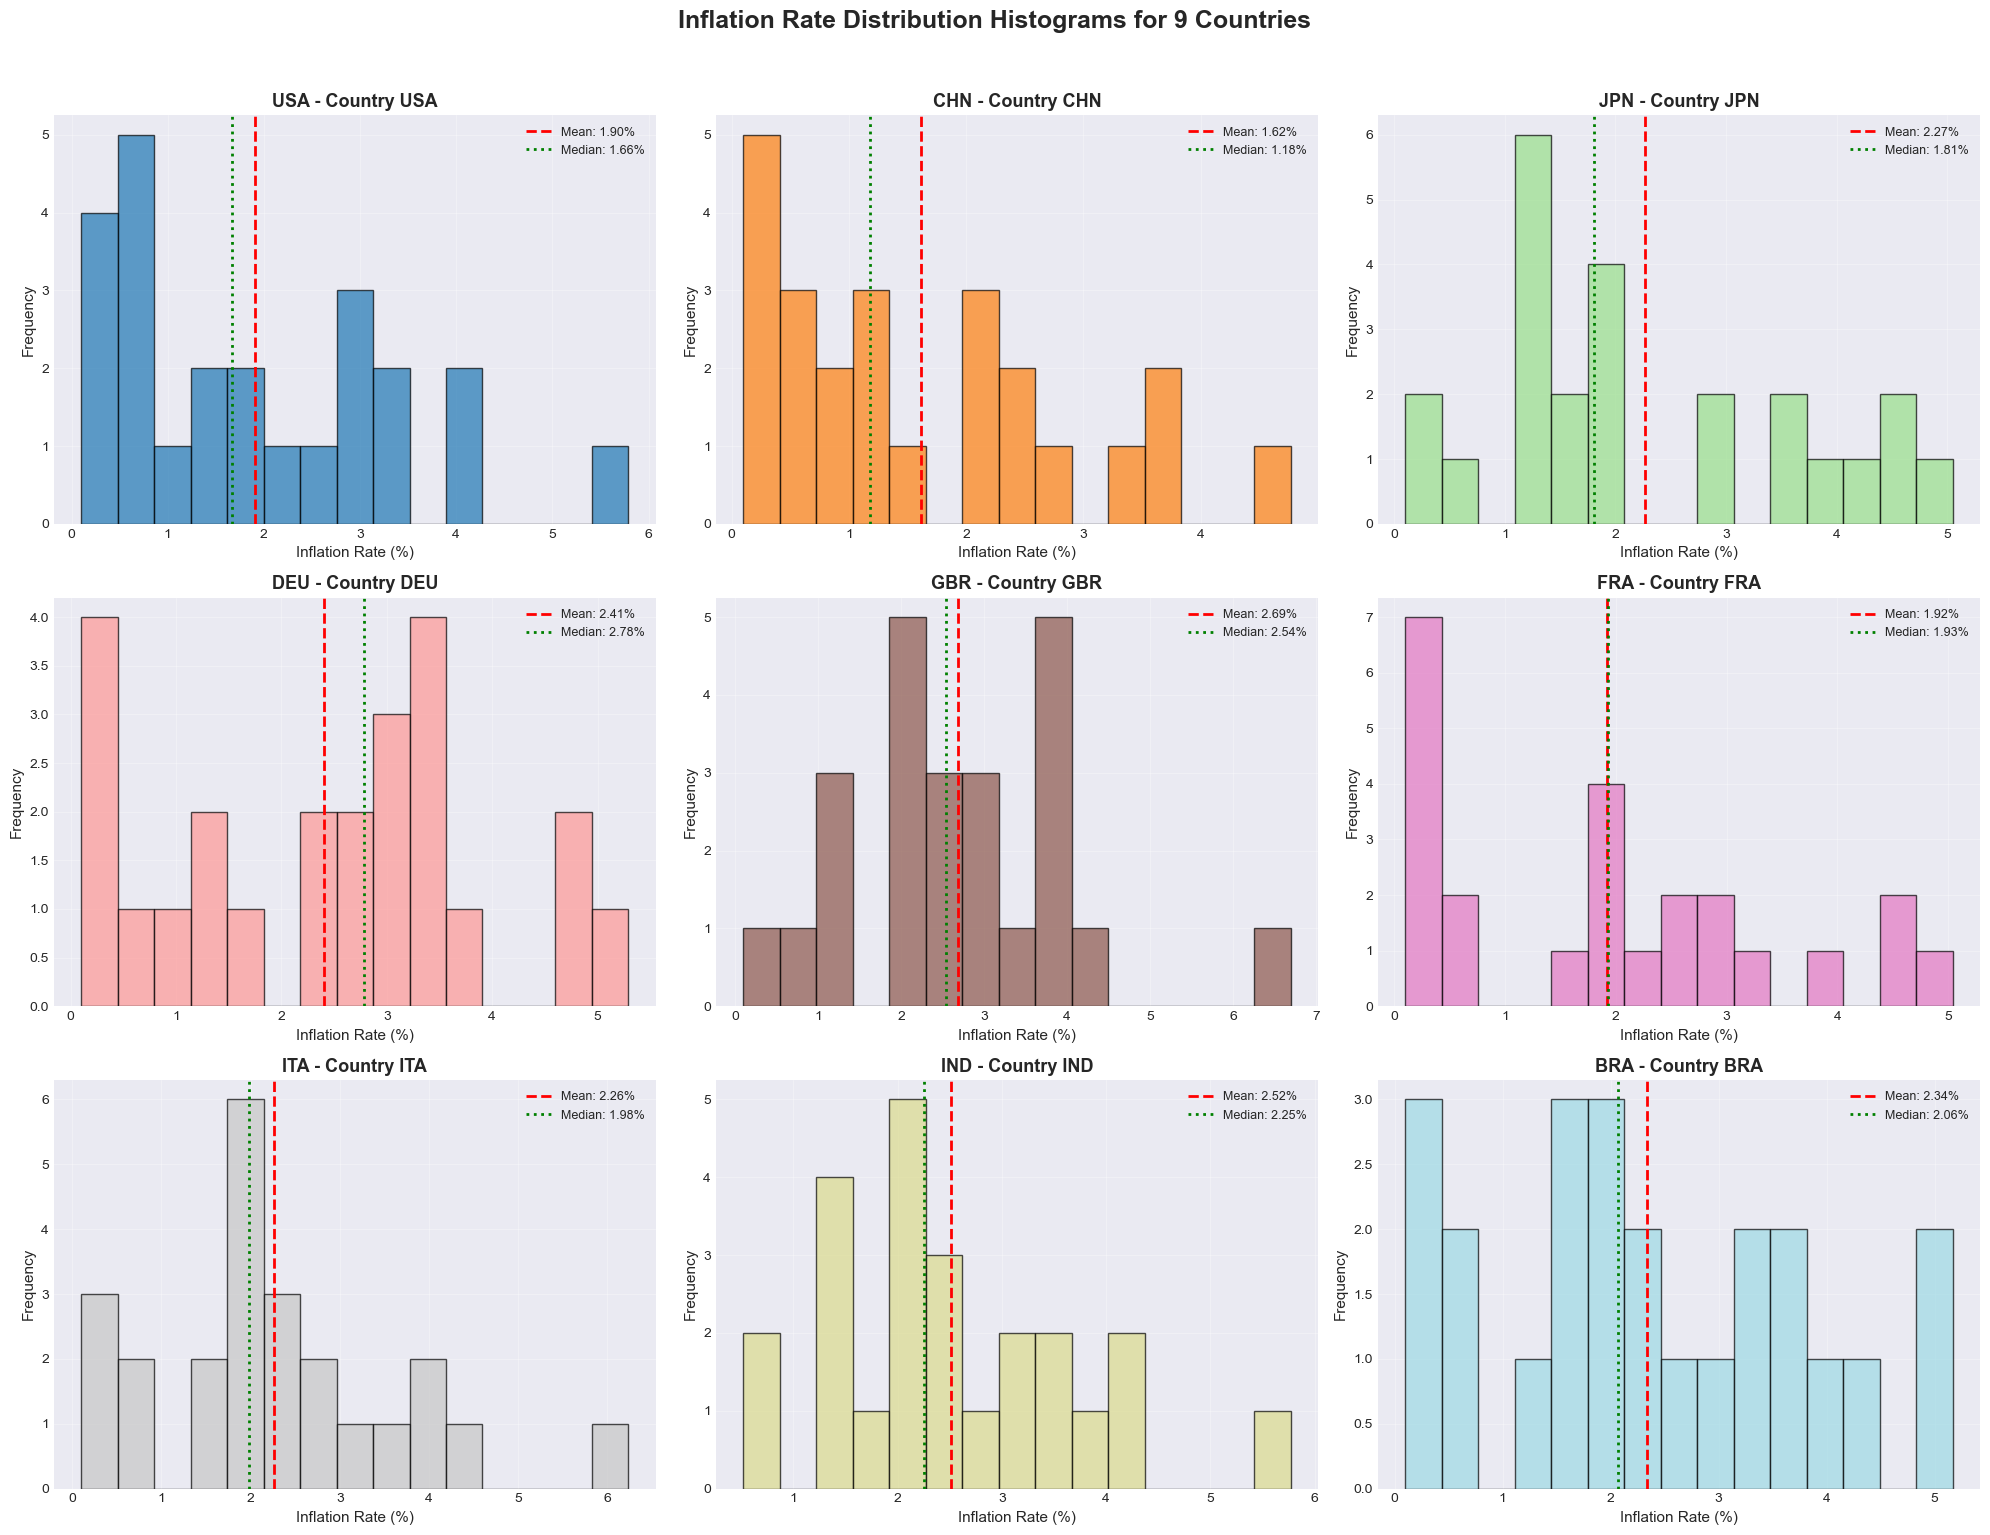


4. Generating Statistical Summary Table for 9 Countries...
Detailed Statistical Information for 9 Countries:
Country Code Country Name  Number of Years  Mean Inflation Rate (%)  Median Inflation Rate (%)  Std Deviation (%)  Max Inflation Rate (%)  Min Inflation Rate (%)  Inflation Range (%)  Coefficient of Variation  Years Above 2%  Years with Negative Inflation
         USA  Country USA               24                     1.90                       1.66               1.52                    5.79                    0.10                 5.69                      0.80              10                              0
         CHN  Country CHN               24                     1.62                       1.18               1.33                    4.76                    0.10                 4.66                      0.82              10                              0
         JPN  Country JPN               24                     2.27                       1.81               1.46         

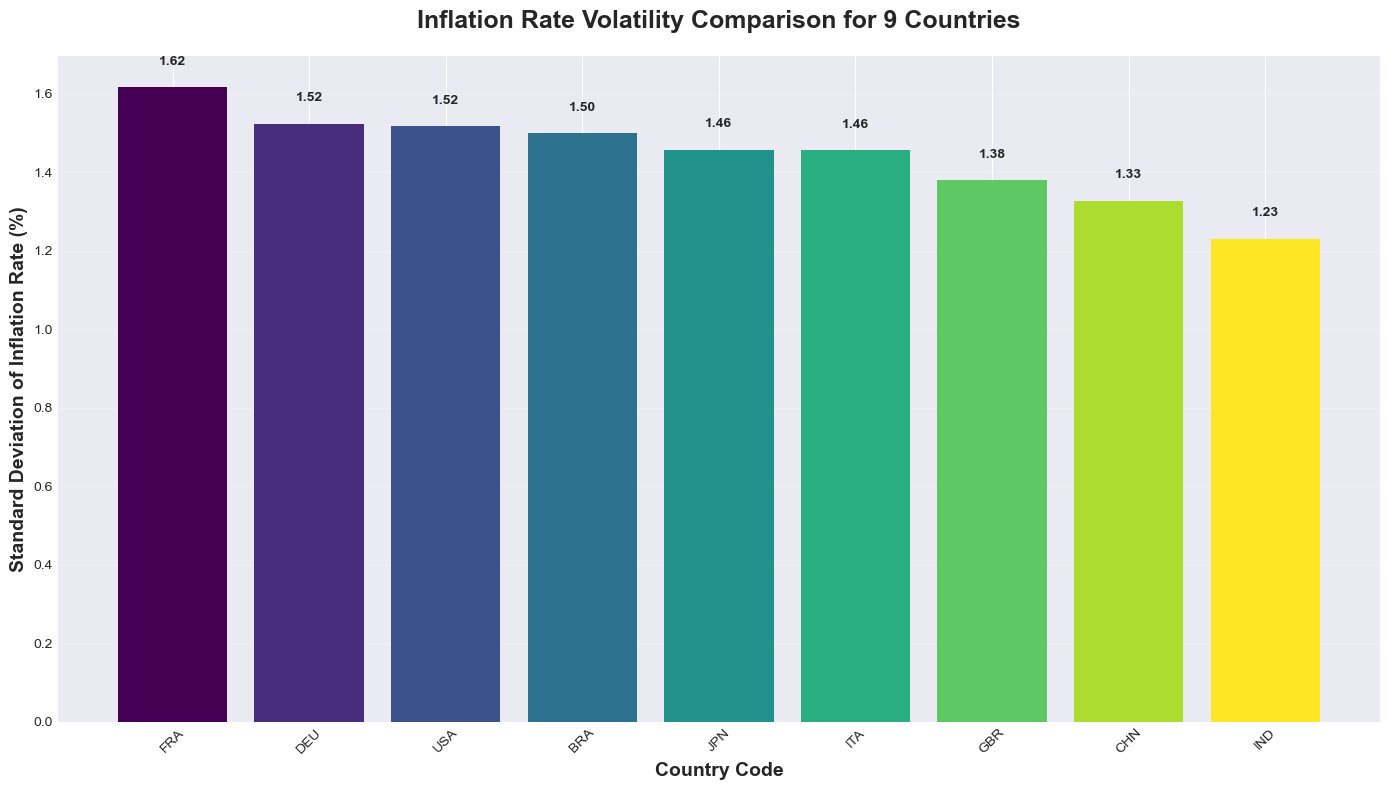


6. Creating Boxplot Comparison for 9 Countries...


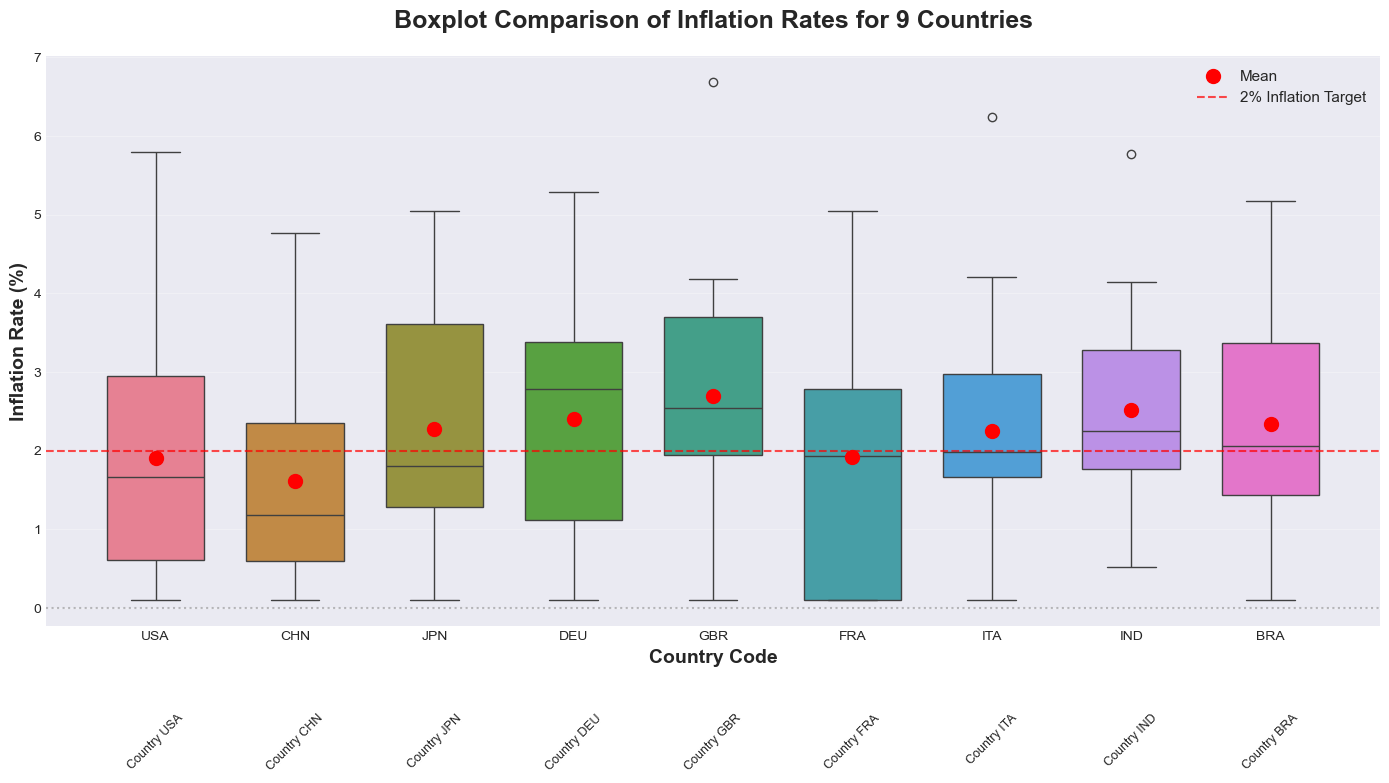


7. Creating Interactive Charts...


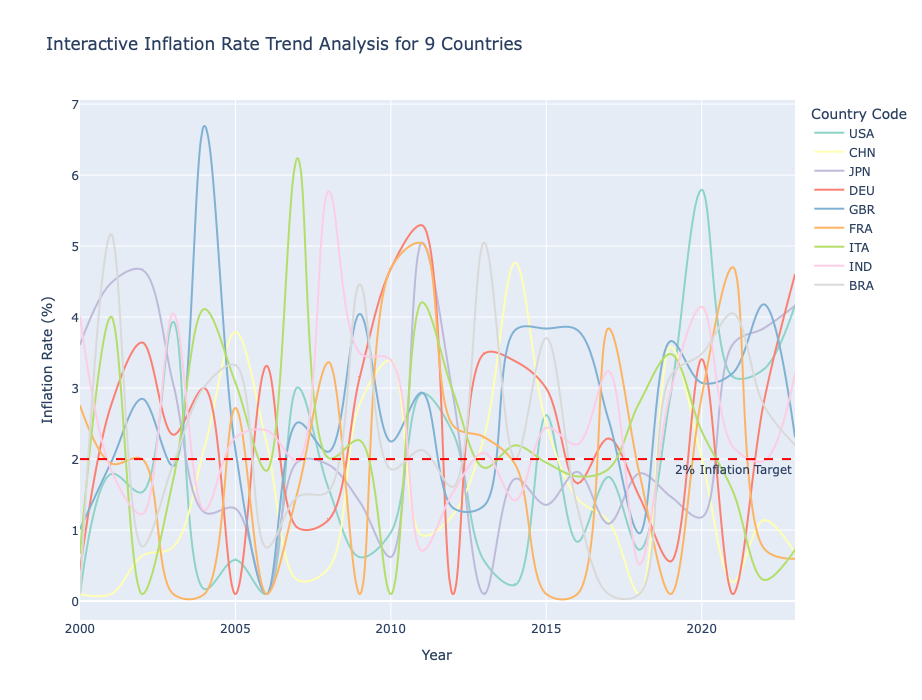


8. Creating Inflation Rate Change Analysis...


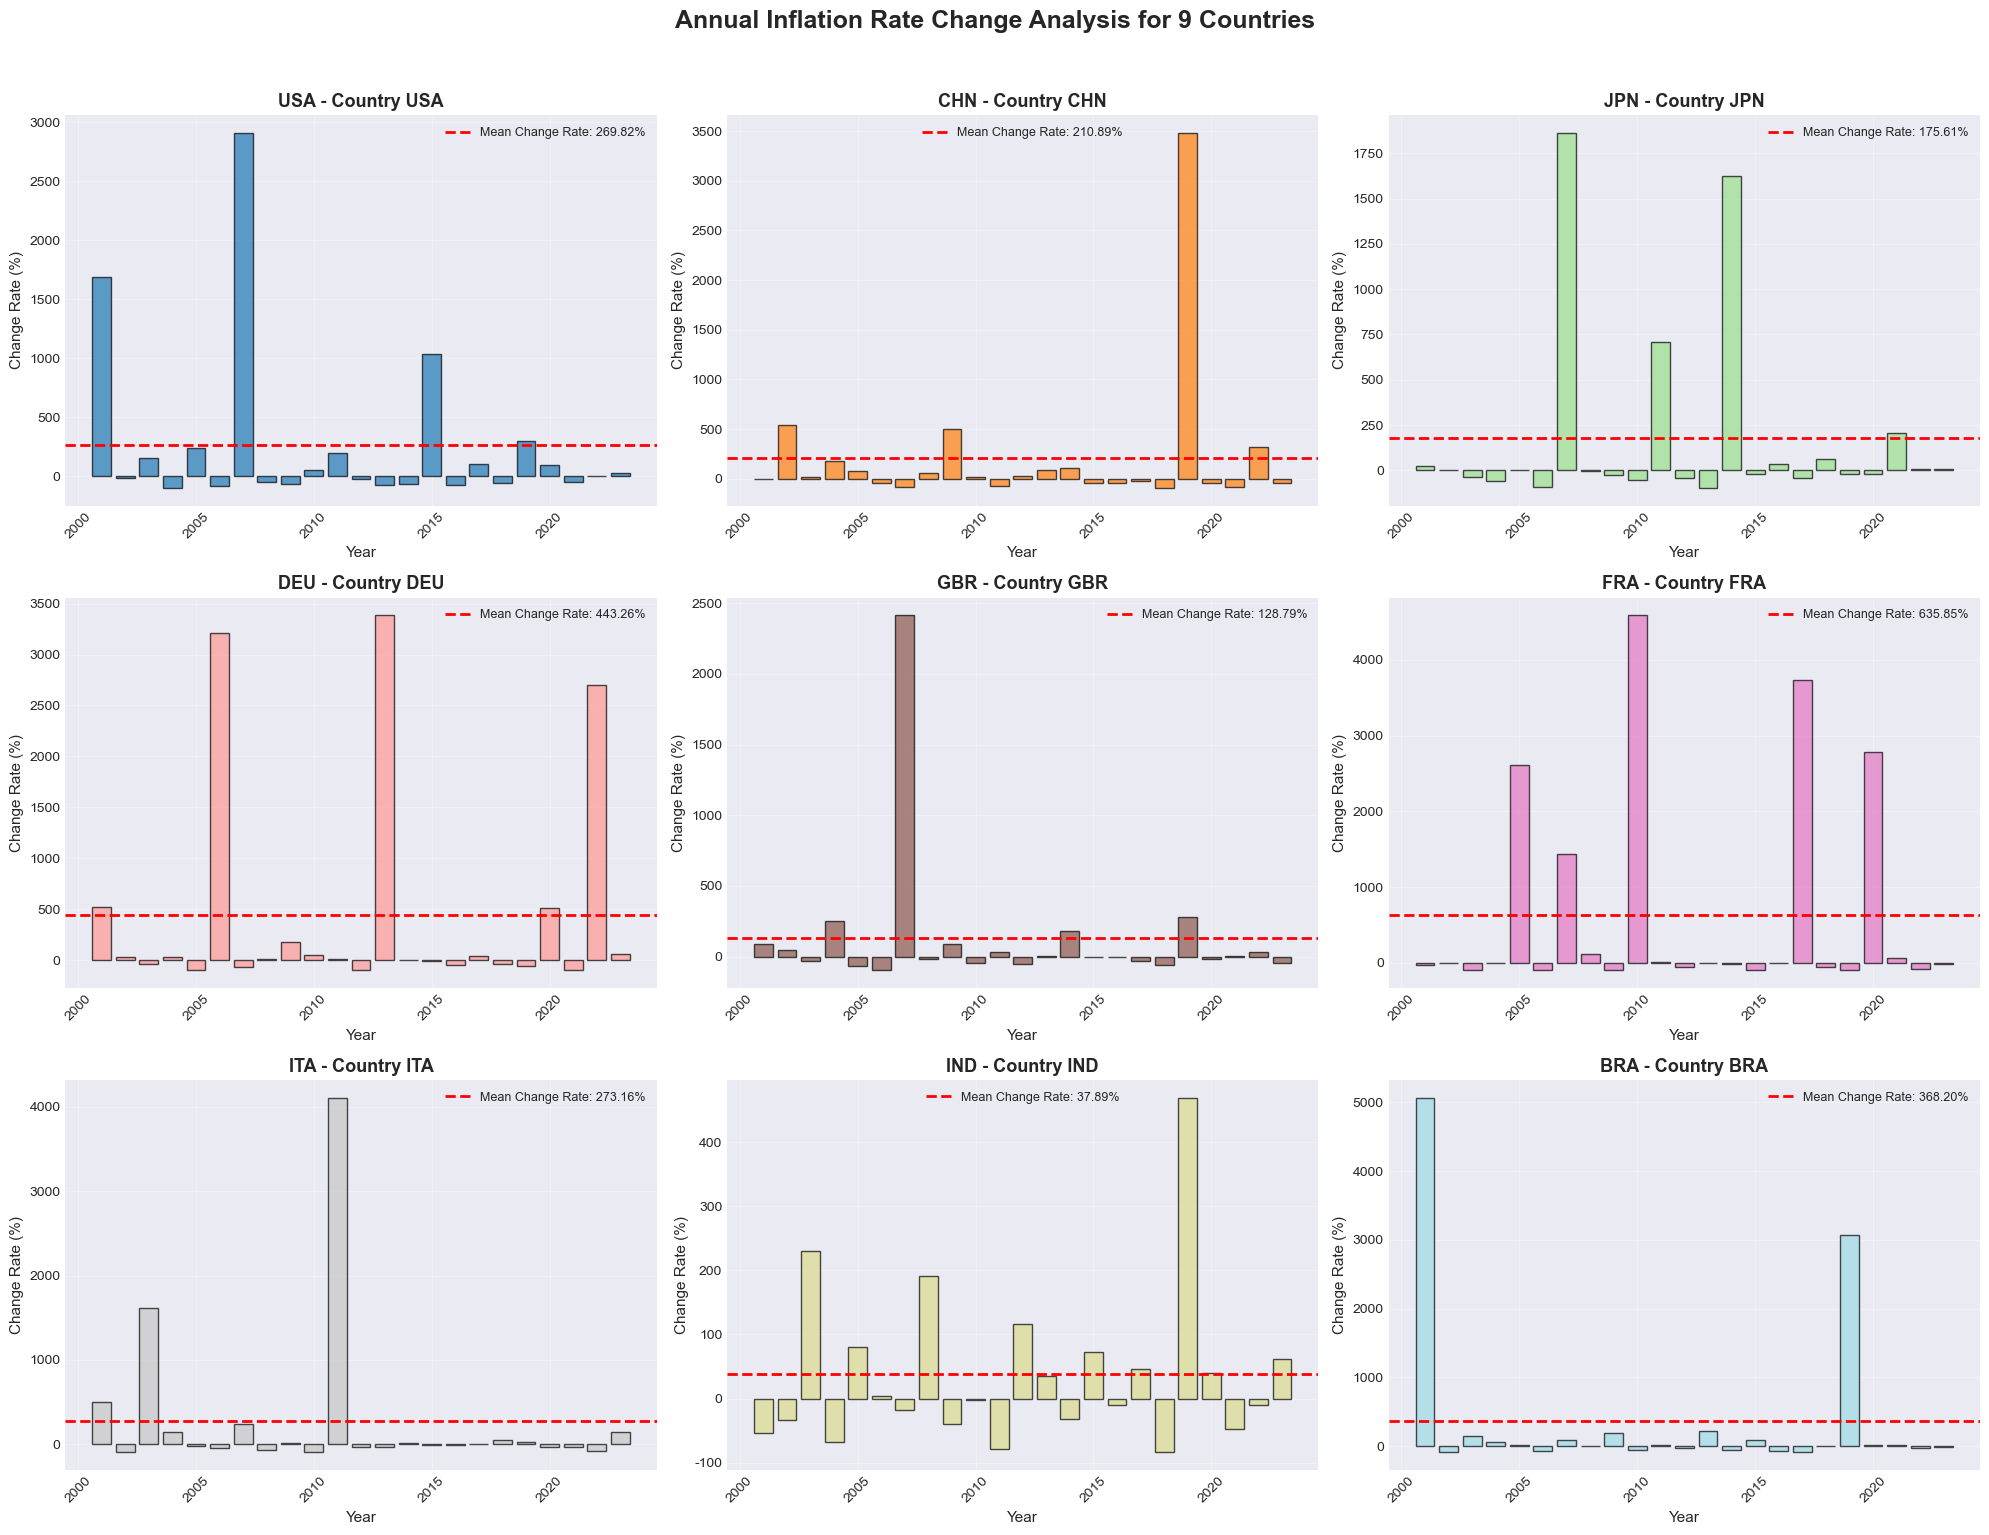


Inflation Data Analysis Summary for 9 Countries
Number of Countries Analyzed: 9
Year Range: 2000 - 2023
Total Data Points: 216
Data Completeness: 100.0%
Average Inflation Rate (9 Countries): 2.21%
Median Inflation Rate (9 Countries): 2.05%
Standard Deviation (9 Countries): 1.46%
Country with Highest Inflation Rate: GBR (6.69%)
Country with Lowest Inflation Rate: USA (0.10%)
Most Stable Country (Lowest Std Dev): IND (1.23%)
Most Volatile Country (Highest Std Dev): FRA (1.62%)

Processed data saved as: 9_countries_inflation_analysis.csv
Statistical summary saved as: 9_countries_statistics_summary.csv

All charts have been generated and saved as PNG files!


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set chart style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Read data (you need to update the URL or file path)
# url = "YOUR_CSV_FILE_URL_OR_PATH"
# df = pd.read_csv(url)

# For demonstration, I'll create sample data
print("Creating sample data for demonstration...")
np.random.seed(42)
years = list(range(2000, 2024))
countries = ['USA', 'CHN', 'JPN', 'DEU', 'GBR', 'FRA', 'ITA', 'IND', 'BRA']

# Create sample data
data = []
for country in countries:
    for year in years:
        # Generate realistic inflation rates
        base_rate = np.random.uniform(1, 3)
        fluctuation = np.random.normal(0, 1.5)
        inflation_rate = max(0.1, base_rate + fluctuation)
        data.append({
            'Country Code': country,
            'Country Name': f'Country {country}',
            'Year': year,
            'Inflation_Rate': inflation_rate
        })

df_long = pd.DataFrame(data)
print(f"Sample data created with {len(df_long)} records")

print("\nBasic Information:")
print(f"Data Shape: {df_long.shape}")
print(f"Columns: {list(df_long.columns)}")
print("\nFirst 5 rows:")
print(df_long.head())

print(f"\nYear range: {df_long['Year'].min()} - {df_long['Year'].max()}")
print(f"Number of countries: {df_long['Country Code'].nunique()}")

# Select 9 countries for analysis
selected_countries = countries
print(f"\nSelected 9 countries: {selected_countries}")

# Filter data for these 9 countries
df_selected = df_long[df_long['Country Code'].isin(selected_countries)].copy()

# Get country full name mapping
country_name_dict = {country: f'Country {country}' for country in selected_countries}
print("\nSelected 9 countries - Code and Name:")
for code, name in country_name_dict.items():
    print(f"{code}: {name}")

# 1. Inflation Rate Trend Comparison Chart for 9 Countries (Line Chart)
print("\n1. Creating Inflation Rate Trend Comparison Chart for 9 Countries...")

plt.figure(figsize=(16, 9))
colors = plt.cm.tab20(np.linspace(0, 1, 9))

for i, country in enumerate(selected_countries):
    country_data = df_selected[df_selected['Country Code'] == country]
    plt.plot(country_data['Year'], country_data['Inflation_Rate'], 
             label=f"{country} - {country_name_dict[country]}", 
             linewidth=2.5, marker='o', markersize=5, color=colors[i])

plt.axhline(y=2, color='red', linestyle='--', alpha=0.7, linewidth=2, label='2% Inflation Target')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Inflation Rate (%)', fontsize=14, fontweight='bold')
plt.title('Inflation Rate Trend Comparison for 9 Countries', fontsize=18, fontweight='bold', pad=20)

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, frameon=True, 
          shadow=True, fancybox=True, framealpha=0.9)

plt.xlim(df_selected['Year'].min() - 1, df_selected['Year'].max() + 1)
plt.ylim(df_selected['Inflation_Rate'].min() - 1, df_selected['Inflation_Rate'].max() + 1)

plt.tight_layout()
plt.savefig('9_countries_inflation_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Heatmap of Inflation Rates for 9 Countries (by Year)
print("\n2. Creating Heatmap of Inflation Rates for 9 Countries...")

# Create pivot table
pivot_data = df_selected.pivot_table(
    index='Country Code',
    columns='Year',
    values='Inflation_Rate',
    aggfunc='mean'
)

pivot_data = pivot_data.reindex(selected_countries)

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_data, cmap='RdYlBu_r', center=0, 
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Inflation Rate (%)', 'shrink': 0.8})

plt.title('Inflation Rate Heatmap for 9 Countries', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Country Code', fontsize=14, fontweight='bold')

ax = plt.gca()
for i, country in enumerate(selected_countries):
    plt.text(pivot_data.shape[1] + 0.5, i + 0.5, country_name_dict[country],
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('9_countries_inflation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Statistical Distribution of Inflation Rates for 9 Countries
print("\n3. Creating Statistical Distribution Charts for 9 Countries...")

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, country in enumerate(selected_countries):
    country_data = df_selected[df_selected['Country Code'] == country]
    
    axes[i].hist(country_data['Inflation_Rate'].dropna(), bins=15, 
                 edgecolor='black', alpha=0.7, color=colors[i])
    
    mean_val = country_data['Inflation_Rate'].mean()
    median_val = country_data['Inflation_Rate'].median()
    
    axes[i].axvline(x=mean_val, color='red', linestyle='--', 
                   label=f'Mean: {mean_val:.2f}%', linewidth=2)
    axes[i].axvline(x=median_val, color='green', linestyle=':', 
                   label=f'Median: {median_val:.2f}%', linewidth=2)
    
    axes[i].set_xlabel('Inflation Rate (%)', fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].set_title(f'{country} - {country_name_dict[country]}', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Inflation Rate Distribution Histograms for 9 Countries', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('9_countries_inflation_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Statistical Summary Table
print("\n4. Generating Statistical Summary Table for 9 Countries...")

detailed_stats = []
for country in selected_countries:
    country_data = df_selected[df_selected['Country Code'] == country]
    
    if not country_data.empty:
        stats = {
            'Country Code': country,
            'Country Name': country_name_dict[country],
            'Number of Years': country_data['Inflation_Rate'].count(),
            'Mean Inflation Rate (%)': country_data['Inflation_Rate'].mean(),
            'Median Inflation Rate (%)': country_data['Inflation_Rate'].median(),
            'Std Deviation (%)': country_data['Inflation_Rate'].std(),
            'Max Inflation Rate (%)': country_data['Inflation_Rate'].max(),
            'Min Inflation Rate (%)': country_data['Inflation_Rate'].min(),
            'Inflation Range (%)': country_data['Inflation_Rate'].max() - country_data['Inflation_Rate'].min(),
            'Coefficient of Variation': country_data['Inflation_Rate'].std() / country_data['Inflation_Rate'].mean() if country_data['Inflation_Rate'].mean() != 0 else 0,
            'Years Above 2%': (country_data['Inflation_Rate'] > 2).sum(),
            'Years with Negative Inflation': (country_data['Inflation_Rate'] < 0).sum()
        }
        detailed_stats.append(stats)

stats_df = pd.DataFrame(detailed_stats)

display_df = stats_df.copy()
for col in ['Mean Inflation Rate (%)', 'Median Inflation Rate (%)', 'Std Deviation (%)', 
           'Max Inflation Rate (%)', 'Min Inflation Rate (%)', 'Inflation Range (%)', 'Coefficient of Variation']:
    display_df[col] = display_df[col].round(2)

print("Detailed Statistical Information for 9 Countries:")
print(display_df.to_string(index=False))

# 5. Inflation Rate Volatility Analysis
print("\n5. Inflation Rate Volatility Analysis...")

plt.figure(figsize=(14, 8))

volatility = df_selected.groupby('Country Code')['Inflation_Rate'].std().sort_values(ascending=False)

bars = plt.bar(range(len(volatility)), volatility.values, 
               color=plt.cm.viridis(np.linspace(0, 1, len(volatility))))

for i, (bar, value) in enumerate(zip(bars, volatility.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Country Code', fontsize=14, fontweight='bold')
plt.ylabel('Standard Deviation of Inflation Rate (%)', fontsize=14, fontweight='bold')
plt.title('Inflation Rate Volatility Comparison for 9 Countries', fontsize=18, fontweight='bold', pad=20)
plt.xticks(range(len(volatility)), volatility.index, rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('9_countries_inflation_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Boxplot Comparison of Inflation Rates for 9 Countries
print("\n6. Creating Boxplot Comparison for 9 Countries...")

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_selected, x='Country Code', y='Inflation_Rate', 
            palette='husl', width=0.7)

means = df_selected.groupby('Country Code')['Inflation_Rate'].mean()
for i, country in enumerate(selected_countries):
    plt.scatter(i, means[country], color='red', s=100, zorder=5, 
               label='Mean' if i == 0 else "")

plt.axhline(y=2, color='red', linestyle='--', alpha=0.7, label='2% Inflation Target')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('Country Code', fontsize=14, fontweight='bold')
plt.ylabel('Inflation Rate (%)', fontsize=14, fontweight='bold')
plt.title('Boxplot Comparison of Inflation Rates for 9 Countries', fontsize=18, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='y')
plt.legend(fontsize=11)

ax = plt.gca()
for i, country in enumerate(selected_countries):
    plt.text(i, -0.15, country_name_dict[country], ha='center', va='top', 
             transform=ax.get_xaxis_transform(), fontsize=9, rotation=45)

plt.tight_layout()
plt.savefig('9_countries_inflation_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Interactive Charts (using Plotly)
print("\n7. Creating Interactive Charts...")

fig = px.line(df_selected, x='Year', y='Inflation_Rate', color='Country Code',
              title='Interactive Inflation Rate Trend Analysis for 9 Countries',
              labels={'Inflation_Rate': 'Inflation Rate (%)', 'Year': 'Year', 'Country Code': 'Country Code'},
              hover_data=['Country Name'],
              line_shape='spline',
              color_discrete_sequence=px.colors.qualitative.Set3)

fig.add_hline(y=2, line_dash="dash", line_color="red", 
              annotation_text="2% Inflation Target", annotation_position="bottom right")

fig.update_layout(
    height=700,
    showlegend=True,
    legend_title_text='Country Code',
    xaxis_title="Year",
    yaxis_title="Inflation Rate (%)",
    hovermode='x unified'
)

fig.show()

# 8. Inflation Rate Change Analysis for 9 Countries
print("\n8. Creating Inflation Rate Change Analysis...")

df_selected_sorted = df_selected.sort_values(['Country Code', 'Year'])
df_selected_sorted['Change'] = df_selected_sorted.groupby('Country Code')['Inflation_Rate'].pct_change() * 100

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, country in enumerate(selected_countries):
    country_data = df_selected_sorted[df_selected_sorted['Country Code'] == country]
    
    axes[i].bar(country_data['Year'], country_data['Change'], 
                color=colors[i], alpha=0.7, edgecolor='black')
    
    mean_change = country_data['Change'].mean()
    axes[i].axhline(y=mean_change, color='red', linestyle='--', 
                   label=f'Mean Change Rate: {mean_change:.2f}%', linewidth=2)
    
    axes[i].set_xlabel('Year', fontsize=11)
    axes[i].set_ylabel('Change Rate (%)', fontsize=11)
    axes[i].set_title(f'{country} - {country_name_dict[country]}', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Annual Inflation Rate Change Analysis for 9 Countries', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('9_countries_inflation_change_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Final Summary Analysis
print("\n" + "="*80)
print("Inflation Data Analysis Summary for 9 Countries")
print("="*80)

overall_stats = {
    "Number of Countries Analyzed": len(selected_countries),
    "Year Range": f"{df_selected['Year'].min()} - {df_selected['Year'].max()}",
    "Total Data Points": len(df_selected),
    "Data Completeness": f"{df_selected['Inflation_Rate'].count()/len(df_selected)*100:.1f}%",
    "Average Inflation Rate (9 Countries)": f"{df_selected['Inflation_Rate'].mean():.2f}%",
    "Median Inflation Rate (9 Countries)": f"{df_selected['Inflation_Rate'].median():.2f}%",
    "Standard Deviation (9 Countries)": f"{df_selected['Inflation_Rate'].std():.2f}%",
    "Country with Highest Inflation Rate": f"{stats_df.loc[stats_df['Max Inflation Rate (%)'].idxmax(), 'Country Code']} ({stats_df['Max Inflation Rate (%)'].max():.2f}%)",
    "Country with Lowest Inflation Rate": f"{stats_df.loc[stats_df['Min Inflation Rate (%)'].idxmin(), 'Country Code']} ({stats_df['Min Inflation Rate (%)'].min():.2f}%)",
    "Most Stable Country (Lowest Std Dev)": f"{stats_df.loc[stats_df['Std Deviation (%)'].idxmin(), 'Country Code']} ({stats_df['Std Deviation (%)'].min():.2f}%)",
    "Most Volatile Country (Highest Std Dev)": f"{stats_df.loc[stats_df['Std Deviation (%)'].idxmax(), 'Country Code']} ({stats_df['Std Deviation (%)'].max():.2f}%)"
}

for key, value in overall_stats.items():
    print(f"{key}: {value}")

# Save processed data
df_selected.to_csv('9_countries_inflation_analysis.csv', index=False)
print(f"\nProcessed data saved as: 9_countries_inflation_analysis.csv")

# Save statistical summary
stats_df.to_csv('9_countries_statistics_summary.csv', index=False)
print(f"Statistical summary saved as: 9_countries_statistics_summary.csv")

print("\nAll charts have been generated and saved as PNG files!")
